In [61]:
# Install the library
# %pip install pythae

In [62]:
import torch
import torchvision.datasets as datasets

device = "cuda" if torch.cuda.is_available() else "cpu"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [63]:
mnist_trainset = datasets.MNIST(root='../../data', train=True, download=True, transform=None)

train_dataset = mnist_trainset.data[:-10000].reshape(-1, 1, 28, 28) / 255.0
eval_dataset = mnist_trainset.data[-10000:].reshape(-1, 1, 28, 28) / 255.0

# train_dataset = train_dataset.float()
# eval_dataset = eval_dataset.float()


In [64]:
from pythae.models import AmortizedDualVAE, AmortizedDualVAEConfig
from pythae.trainers import BaseTrainerConfig
from pythae.pipelines.training import TrainingPipeline


In [65]:
config = BaseTrainerConfig(
    output_dir='my_amortized_dual_vae',
    learning_rate=1e-4,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_epochs=10,  # Increase for more training
    optimizer_cls="AdamW",
    optimizer_params={"weight_decay": 0.05, "betas": (0.91, 0.99)}
)

model_config = AmortizedDualVAEConfig(
    input_dim=(1, 28, 28),
    latent_dim=4,
)

model = AmortizedDualVAE(
    model_config=model_config
)


In [66]:
# from pythae.trainers.training_callbacks import WandbCallback
# callbacks = []
# wandb_cb = WandbCallback()
# wandb_cb.setup(training_config=config, # training config
#     model_config=model_config, # model config
#     project_name="memvae", # specify your wandb project
# )
# callbacks.append(wandb_cb)

In [67]:
pipeline = TrainingPipeline(
    training_config=config,
    model=model
)


In [68]:
pipeline(
    train_data=train_dataset,
    eval_data=eval_dataset,
    # callbacks=callbacks
)


Preprocessing train data...


Checking train dataset...
Preprocessing eval data...

Checking eval dataset...
Using Base Trainer

Model passed sanity check !
Ready for training.

Created my_amortized_dual_vae/AmortizedDualVAE_training_2025-10-20_18-28-22. 
Training config, checkpoints and final model will be saved here.

Training params:
 - max_epochs: 10
 - per_device_train_batch_size: 64
 - per_device_eval_batch_size: 64
 - checkpoint saving every: None
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.91, 0.99)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.05
)
Scheduler: None

Successfully launched training !



reconstruction loss: 93.05888366699219 score proxy: 0.02627706527709961 dual proxy: 1.4944103956222534 moment loss: 70.35364532470703 lambda reg: 0.0013967229751870036 reencode loss: 0.04145088419318199


Training of epoch 1/10:   0%|          | 0/782 [00:00<?, ?batch/s]

reconstruction loss: 94.09720611572266 score proxy: 0.024907059967517853 dual proxy: 3.5633316040039062 moment loss: 212.59695434570312 lambda reg: 0.0013508946867659688 reencode loss: 0.0419294610619545
reconstruction loss: 92.30055236816406 score proxy: 0.0038194977678358555 dual proxy: 0.3489970266819 moment loss: 47.2069206237793 lambda reg: 0.0013994349865242839 reencode loss: 0.04385236278176308
reconstruction loss: 90.57798767089844 score proxy: -0.002244402654469013 dual proxy: -0.473848432302475 moment loss: 10.544977188110352 lambda reg: 0.0015824795700609684 reencode loss: 0.04486113041639328
reconstruction loss: 89.73597717285156 score proxy: -0.0013681490672752261 dual proxy: -0.49769121408462524 moment loss: 3.268219470977783 lambda reg: 0.001712866360321641 reencode loss: 0.04933347553014755
reconstruction loss: 88.86448669433594 score proxy: -5.080972914583981e-05 dual proxy: -0.5667448043823242 moment loss: 1.2226437330245972 lambda reg: 0.0018984758062288165 reencode 

...

--------------------------------------------------------------------------
Train loss: 31.0532
Eval loss: 23.5773
--------------------------------------------------------------------------


reconstruction loss: 22.284221649169922 score proxy: -0.879400372505188 dual proxy: 122.37104797363281 moment loss: 148.44248962402344 lambda reg: 1.3730098009109497 reencode loss: 0.24753543734550476
reconstruction loss: 22.83444595336914 score proxy: -0.535757839679718 dual proxy: 118.48234558105469 moment loss: 143.0072784423828 lambda reg: 1.4105709791183472 reencode loss: 0.2819998264312744
reconstruction loss: 21.96017837524414 score proxy: -0.5090538859367371 dual proxy: 126.83948516845703 moment loss: 146.6387939453125 lambda reg: 1.4179741144180298 reencode loss: 0.19598986208438873
reconstruction loss: 21.787939071655273 score proxy: -0.8250213861465454 dual proxy: 121.56536865234375 moment loss: 149.55130004882812 lambda reg: 1.4081943035125732 reencode loss: 0.2653551995754242
reconstruction loss: 21.587730407714844 score proxy: -1.537253975868225 dual proxy: 93.00059509277344 moment loss: 126.96328735351562 lambda reg: 1.4057930707931519 reencode loss: 0.23838020861148834


Training of epoch 2/10:   0%|          | 0/782 [00:00<?, ?batch/s]

reconstruction loss: 22.19308090209961 score proxy: -1.4328304529190063 dual proxy: 107.99518585205078 moment loss: 135.88327026367188 lambda reg: 1.4036285877227783 reencode loss: 0.2566094398498535
reconstruction loss: 21.69702911376953 score proxy: -0.9577393531799316 dual proxy: 118.26295471191406 moment loss: 143.47833251953125 lambda reg: 1.3780966997146606 reencode loss: 0.25970450043678284
reconstruction loss: 24.183889389038086 score proxy: -0.7160494923591614 dual proxy: 125.1600341796875 moment loss: 152.59542846679688 lambda reg: 1.4231213331222534 reencode loss: 0.21443749964237213
reconstruction loss: 22.502073287963867 score proxy: -1.044951319694519 dual proxy: 116.52022552490234 moment loss: 159.91761779785156 lambda reg: 1.4220468997955322 reencode loss: 0.2720537781715393
reconstruction loss: 21.928730010986328 score proxy: -0.7063678503036499 dual proxy: 136.09051513671875 moment loss: 185.01812744140625 lambda reg: 1.4298979043960571 reencode loss: 0.21260593831539

ArithmeticError: NaN detected in train loss

In [ ]:
import os
from pythae.models import AutoModel


In [ ]:
last_training = sorted(os.listdir(config.output_dir))[-1]
trained_model = AutoModel.load_from_folder(os.path.join(config.output_dir, last_training, 'final_model'))
trained_model = trained_model.to(device)
trained_model.eval()


/home/lau/dl/benchmark_VAE/src/pythae/models/base/base_model.py:357: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_weights = torch.load(path_to_model_weights, map_loca

AmortizedDualVAE(
  (decoder): Decoder_AE_MLP(
    (layers): ModuleList(
      (0): Sequential(
        (0): Linear(in_features=4, out_features=512, bias=True)
        (1): ReLU()
      )
      (1): Sequential(
        (0): Linear(in_features=512, out_features=784, bias=True)
        (1): Sigmoid()
      )
    )
  )
  (encoder): MomentsEncoderMLP(
    (layers): ModuleList(
      (0): Sequential(
        (0): Linear(in_features=784, out_features=512, bias=True)
        (1): ReLU()
      )
      (1): Sequential(
        (0): Linear(in_features=512, out_features=512, bias=True)
        (1): ReLU()
      )
    )
    (head): Linear(in_features=512, out_features=69, bias=True)
  )
  (lambda_net): LambdaNetMLP(
    (net): Sequential(
      (0): Linear(in_features=69, out_features=512, bias=True)
      (1): ReLU()
      (2): Linear(in_features=512, out_features=512, bias=True)
      (3): ReLU()
      (4): Linear(in_features=512, out_features=69, bias=True)
    )
  )
)

## Sampling with the energy-based latent prior


In [ ]:
import matplotlib.pyplot as plt

def sample_amortized_dual_vae(model, num_samples=25, reference_batch=None):
    device = next(model.parameters()).device
    model.eval()
    with torch.no_grad():
        if reference_batch is None:
            idx = torch.randint(0, train_dataset.shape[0], (num_samples,))
            reference_batch = train_dataset[idx]
        else:
            reference_batch = reference_batch[:num_samples]
        reference_batch = reference_batch.to(device)
        moments = model.encoder(reference_batch)["embedding"]
        lam = model.lambda_net(moments)
        latent_samples = model.sampler.sample(lam, model.basis)[:, -1, :]
        decoded = model.decoder(latent_samples)["reconstruction"]
    return decoded.cpu()


In [ ]:
generated = sample_amortized_dual_vae(trained_model, num_samples=25)


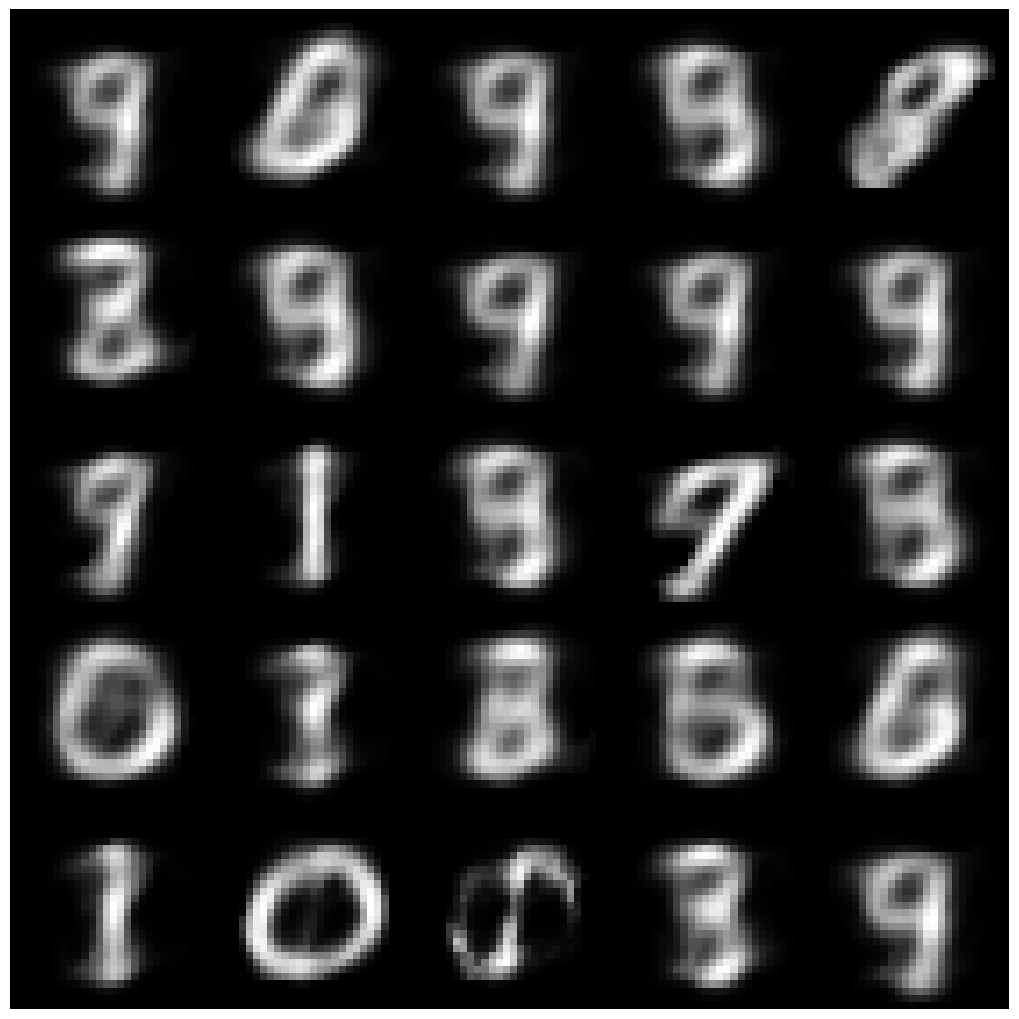

In [ ]:
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(10, 10))

for i in range(5):
    for j in range(5):
        axes[i][j].imshow(generated[i*5 + j].cpu().squeeze(0), cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)


## Visualizing reconstructions


In [ ]:
reconstructions = trained_model.reconstruct(eval_dataset[:25].to(device)).detach().cpu()


reconstruction loss: 17.80401611328125 score proxy: -1.0180599689483643 dual proxy: 532.9595336914062 moment loss: 721.50244140625 lambda reg: 1.925032138824463 reencode loss: 0.3830419182777405


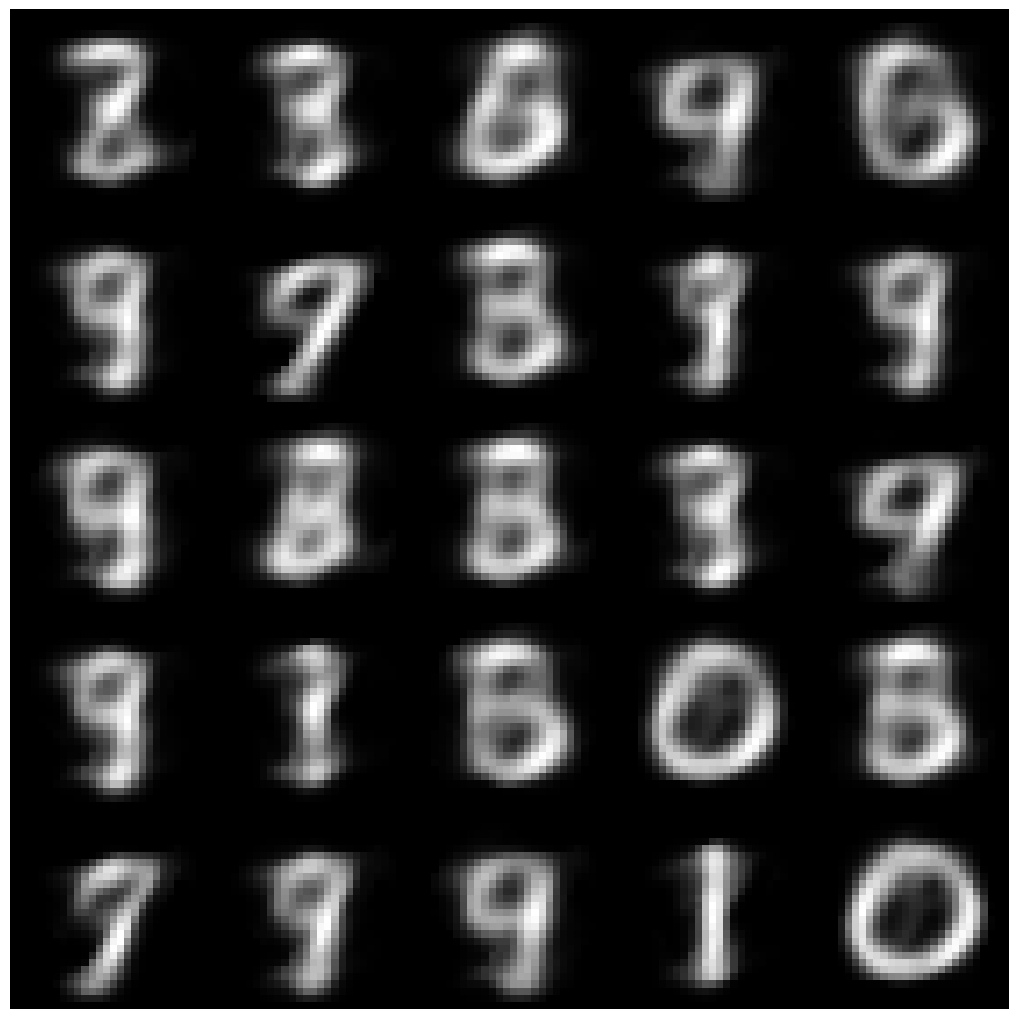

In [ ]:
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(10, 10))

for i in range(5):
    for j in range(5):
        axes[i][j].imshow(reconstructions[i*5 + j].cpu().squeeze(0), cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)


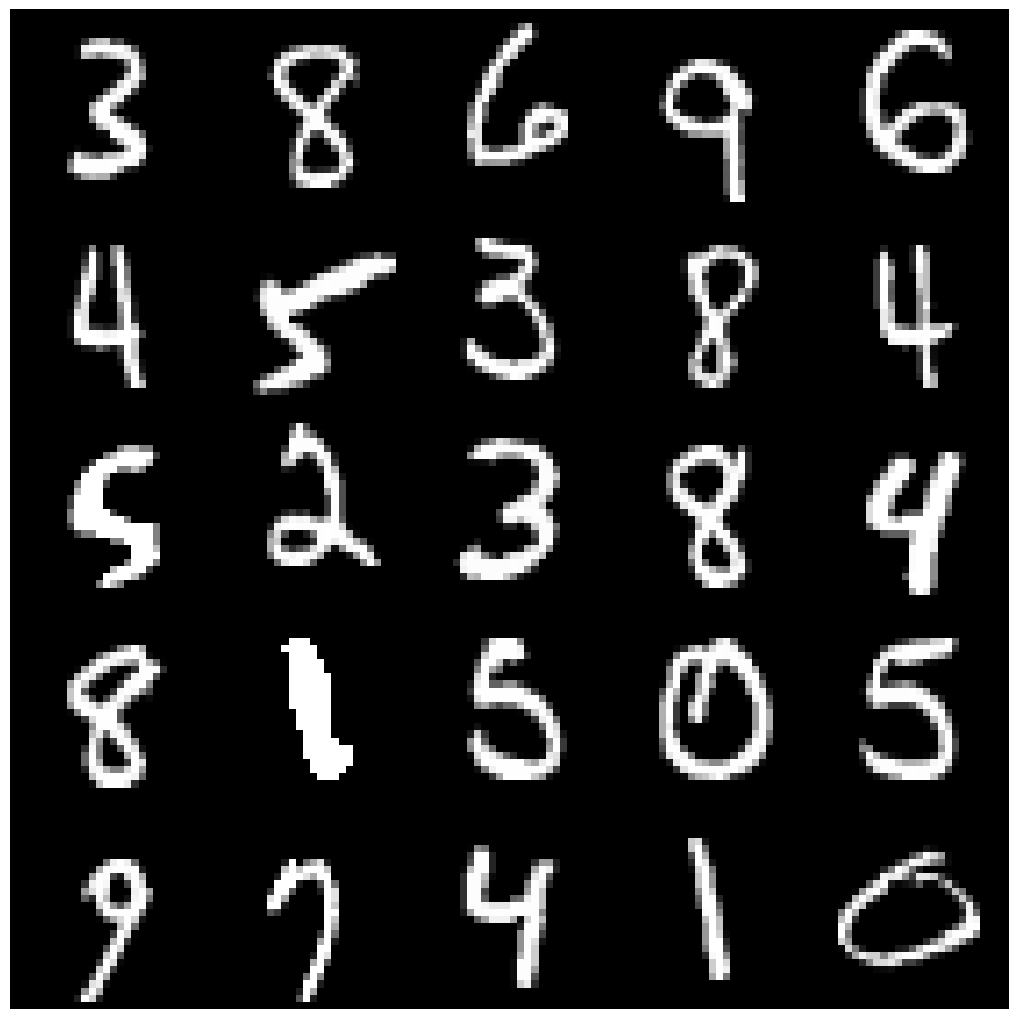

In [ ]:
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(10, 10))

for i in range(5):
    for j in range(5):
        axes[i][j].imshow(eval_dataset[i*5 + j].cpu().squeeze(0), cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)


## Visualizing interpolations


In [ ]:
interpolations = trained_model.interpolate(
    eval_dataset[:5].to(device),
    eval_dataset[5:10].to(device),
    granularity=10
).detach().cpu()


reconstruction loss: 17.24927520751953 score proxy: -2.7527198791503906 dual proxy: 521.1807861328125 moment loss: 554.905517578125 lambda reg: 1.916289210319519 reencode loss: 0.19937525689601898
reconstruction loss: 19.62904930114746 score proxy: 0.31827327609062195 dual proxy: 541.3217163085938 moment loss: 879.1998291015625 lambda reg: 1.8475399017333984 reencode loss: 0.47403061389923096


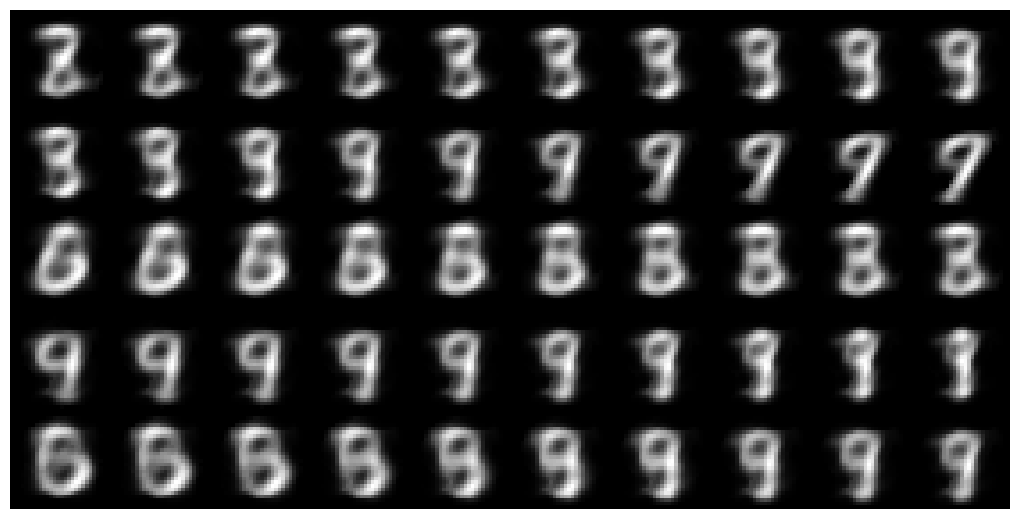

In [ ]:
fig, axes = plt.subplots(nrows=5, ncols=10, figsize=(10, 5))

for i in range(5):
    for j in range(10):
        axes[i][j].imshow(interpolations[i, j].cpu().squeeze(0), cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)
